# PCA Task on Iris.csv

This notebook loads Iris.csv, explores features, plots correlations, applies PCA with 3 components, creates a biplot, runs hierarchical and k-means clustering, and compares correlations before and after PCA.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score

In [3]:
# 1) Load Iris.csv
iris_df = pd.read_csv("Iris.csv")

# Keep all numeric feature columns and species labels
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
X = iris_df[feature_cols]
y = iris_df["Species"]

# 3) Explore features and statistics
print("Dataset shape:", iris_df.shape)
print("Feature columns:", feature_cols)
display(iris_df.head())
display(X.describe())

Dataset shape: (150, 6)
Feature columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


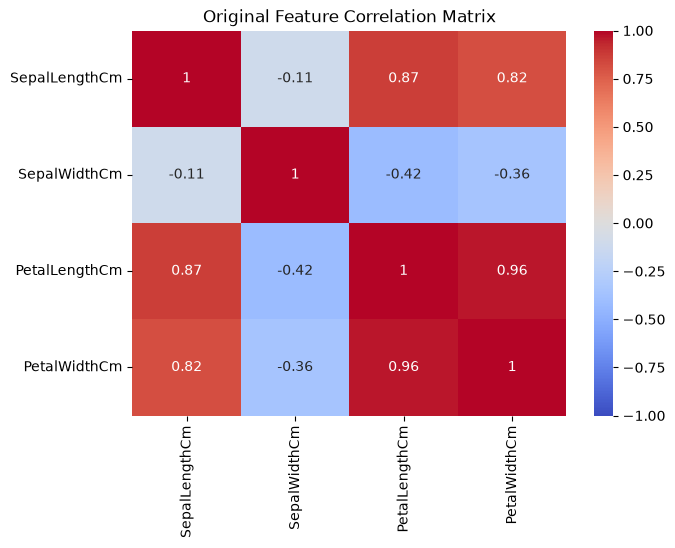

In [4]:
# 4) Correlation plot of original features
corr_original = X.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_original, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Original Feature Correlation Matrix")
plt.show()

In [5]:
# 5) Scale data and apply PCA with n_components = 3
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_cols = ["PC1", "PC2", "PC3"]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", np.round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio: [0.7277 0.2303 0.0368]
Total explained variance: 0.9948


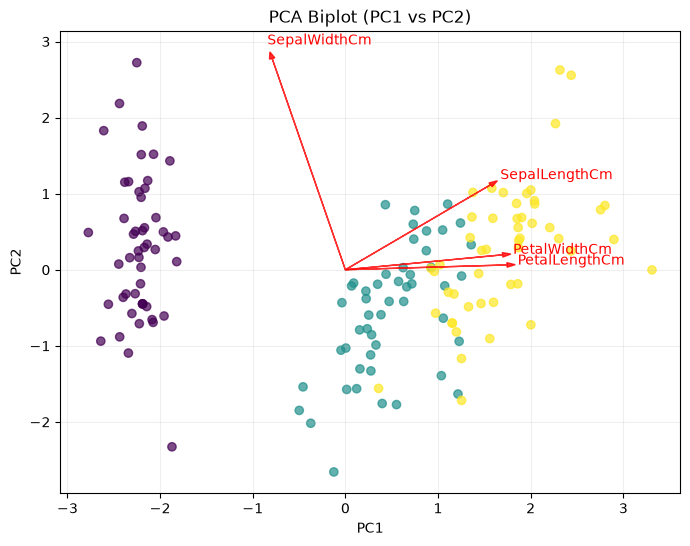

In [6]:
# 6) Biplot using first two principal components
species_codes, species_names = pd.factorize(y)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=species_codes, cmap="viridis", alpha=0.7)

for i, feature in enumerate(feature_cols):
    plt.arrow(
        0,
        0,
        pca.components_[0, i] * 3,
        pca.components_[1, i] * 3,
        color="red",
        alpha=0.8,
        head_width=0.06,
    )
    plt.text(
        pca.components_[0, i] * 3.2,
        pca.components_[1, i] * 3.2,
        feature,
        color="red",
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot (PC1 vs PC2)")
plt.grid(alpha=0.2)
plt.show()

In [7]:
# 7) Hierarchical clustering on PCA-transformed data
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(X_pca)

hc_ari = adjusted_rand_score(y, hc_labels)
print(f"Hierarchical clustering ARI: {hc_ari:.3f}")
print("Identified 3 species well?", "Yes" if hc_ari >= 0.70 else "Partially")

Hierarchical clustering ARI: 0.654
Identified 3 species well? Partially


In [8]:
# 7) K-means clustering on PCA-transformed data
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_pca)

km_ari = adjusted_rand_score(y, km_labels)
print(f"K-means clustering ARI: {km_ari:.3f}")
print("Identified 3 species well?", "Yes" if km_ari >= 0.70 else "Partially")

K-means clustering ARI: 0.620
Identified 3 species well? Partially


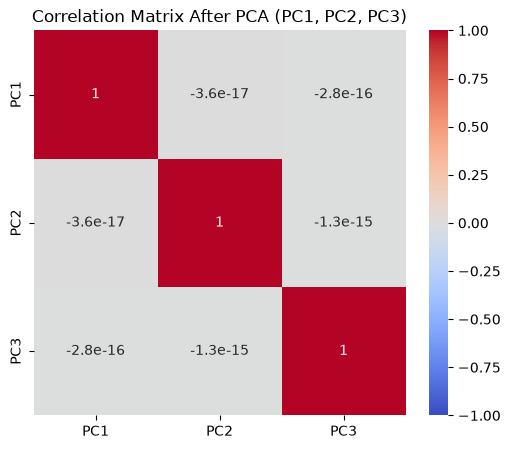

Comparison:
- Original features show several strong positive/negative correlations.
- PCA components are nearly uncorrelated, so redundancy is reduced.


In [9]:
# 8) Correlation plot after PCA and comparison
corr_pca = pca_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_pca, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix After PCA (PC1, PC2, PC3)")
plt.show()

print("Comparison:")
print("- Original features show several strong positive/negative correlations.")
print("- PCA components are nearly uncorrelated, so redundancy is reduced.")